<a href="https://colab.research.google.com/github/mathsrm/fcd-exploratory-data-analysis-productivity/blob/main/notebooks/P2FCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2ª Prova — Fundamentos em Ciência de Dados

**Nome:** Matheus Sanches Raimundo Mendonça  
**Número USP:** 16837181


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

## Leitura do banco de dados

O conjunto de dados contém informações de funcionários e será usado para investigar, de forma exploratória, quais características parecem estar associadas a níveis mais altos ou mais baixos de produtividade.

In [ ]:
df = pd.read_csv('DadoseDecisoes.csv')
df.head()

,ID,Idade,Gênero,Departamento,Salário,Horas_Trabalhadas,Produtividade,Satisfação,Tempo_Empresa,Cursos_Realizados,Home_Office
0,1,34,Masculino,RH,3848.89,36,84.89,94.33,0,4,Não
1,2,39,Feminino,Vendas,2536.32,48,107.84,98.62,4,9,Sim
2,3,39,Masculino,Marketing,7377.81,44,95.66,80.23,11,6,Sim
3,4,27,Feminino,Vendas,2536.32,40,88.89,94.63,8,1,Sim
4,5,41,Feminino,Vendas,2536.32,37,80.97,86.44,11,12,Não


In [ ]:
df.columns

Index(['ID', 'Idade', 'Gênero', 'Departamento', 'Salário', 'Horas_Trabalhadas',
       'Produtividade', 'Satisfação', 'Tempo_Empresa', 'Cursos_Realizados',
       'Home_Office'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 230 non-null    int64  
 1   Idade              230 non-null    int64  
 2   Gênero             230 non-null    object 
 3   Departamento       230 non-null    object 
 4   Salário            230 non-null    float64
 5   Horas_Trabalhadas  230 non-null    int64  
 6   Produtividade      230 non-null    float64
 7   Satisfação         230 non-null    float64
 8   Tempo_Empresa      230 non-null    int64  
 9   Cursos_Realizados  230 non-null    int64  
 10  Home_Office        230 non-null    object 
dtypes: float64(3), int64(5), object(3)
memory usage: 19.9+ KB


In [ ]:
round(df.describe(), 2)

,ID,Idade,Salário,Horas_Trabalhadas,Produtividade,Satisfação,Tempo_Empresa,Cursos_Realizados
count,230.00,230.00,230.00,230.00,230.00,230.00,230.00,230.00
mean,115.50,30.55,8029.97,38.85,87.85,86.15,6.77,5.20
std,66.54,8.22,6556.33,5.82,12.24,12.06,5.96,4.22
min,1.00,18.00,2536.32,30.00,65.74,39.42,0.00,0.00
25%,58.25,24.00,2536.32,34.00,77.12,77.57,1.00,2.00
50%,115.50,29.00,5667.56,38.00,87.04,87.73,6.00,5.00
75%,172.75,35.00,12129.21,44.00,98.42,96.19,11.00,8.00
max,230.00,54.00,29052.82,48.00,112.06,100.00,30.00,20.00


A base possui 230 observações e 11 variáveis originais. A variável `ID` é apenas um identificador dos funcionários e, por isso, não será interpretada como variável explicativa da produtividade.

A inspeção inicial da base foi realizada por meio de `df.info()` e `df.describe()`. O comando `df.info()` permite verificar a quantidade de observações não nulas em cada coluna, os tipos de dados lidos pelo pandas e a dimensão geral da base. Já `df.describe()` fornece medidas descritivas iniciais das variáveis quantitativas, como média, desvio-padrão, mínimo, quartis e máximo.

Como todas as colunas apresentam 230 entradas não nulas, não há indicação de valores ausentes na base analisada. Portanto, não foi necessário remover registros ou imputar valores.

## Questão (a): criação da variável `Produtividade_bin`

A classificação solicitada é:

- **Alta produtividade:** funcionários com produtividade acima da mediana;
- **Baixa produtividade:** funcionários com produtividade abaixo ou igual à mediana.

Assim, a mediana é usada como ponto de corte.

In [ ]:
mediana_produtividade = df['Produtividade'].median()
mediana_produtividade

87.04

In [ ]:
df['Produtividade_bin'] = np.where(df['Produtividade'] > mediana_produtividade, 'Alta', 'Baixa')
pd.crosstab(index=df['Produtividade_bin'], columns='Frequência')

col_0,Frequência
Produtividade_bin,
Alta,114
Baixa,116


In [ ]:
pd.crosstab(index=df['Produtividade_bin'], columns='Frequência relativa', normalize='columns')

col_0,Frequência relativa
Produtividade_bin,
Alta,0.495652
Baixa,0.504348


A mediana observada de `Produtividade` é **87,04**. Com essa regra, foram classificados **114 funcionários como Alta produtividade** e **116 como Baixa produtividade**.

## Questão (b): tipo de cada variável

A tabela abaixo classifica cada variável segundo a natureza estatística: quantitativa discreta, quantitativa contínua, qualitativa nominal ou qualitativa ordinal.

In [ ]:
tipos_variaveis = pd.DataFrame({
    'Variável': [
        'ID',
        'Idade',
        'Gênero',
        'Departamento',
        'Salário',
        'Horas_Trabalhadas',
        'Produtividade',
        'Satisfação',
        'Tempo_Empresa',
        'Cursos_Realizados',
        'Home_Office',
        'Produtividade_bin'
    ],
    'Tipo': [
        'Identificador',
        'Quantitativa discreta',
        'Qualitativa nominal',
        'Qualitativa nominal',
        'Quantitativa contínua',
        'Quantitativa discreta',
        'Quantitativa contínua',
        'Quantitativa contínua',
        'Quantitativa discreta',
        'Quantitativa discreta',
        'Qualitativa nominal',
        'Qualitativa ordinal'
    ]
})

tipos_variaveis

,Variável,Tipo
0,ID,Identificador
1,Idade,Quantitativa discreta
2,Gênero,Qualitativa nominal
3,Departamento,Qualitativa nominal
4,Salário,Quantitativa contínua
5,Horas_Trabalhadas,Quantitativa discreta
6,Produtividade,Quantitativa contínua
7,Satisfação,Quantitativa contínua
8,Tempo_Empresa,Quantitativa discreta
9,Cursos_Realizados,Quantitativa discreta


## Questão (c): análise das variáveis qualitativas

Para as variáveis qualitativas, serão usadas tabelas de frequência absoluta, frequência relativa e gráficos de barras/setores. As variáveis qualitativas originais são `Gênero`, `Departamento` e `Home_Office`. A variável criada `Produtividade_bin` também é qualitativa ordinal.

In [ ]:
qualitativas = ['Gênero', 'Departamento', 'Home_Office', 'Produtividade_bin']

for var in qualitativas:
    display(pd.crosstab(index=df[var], columns='Frequência'))
    print("\n")

col_0,Frequência
Gênero,
Feminino,102
Masculino,128


col_0,Frequência
Departamento,
Marketing,49
RH,45
TI,74
Vendas,62


col_0,Frequência
Home_Office,
Não,115
Sim,115


col_0,Frequência
Produtividade_bin,
Alta,114
Baixa,116


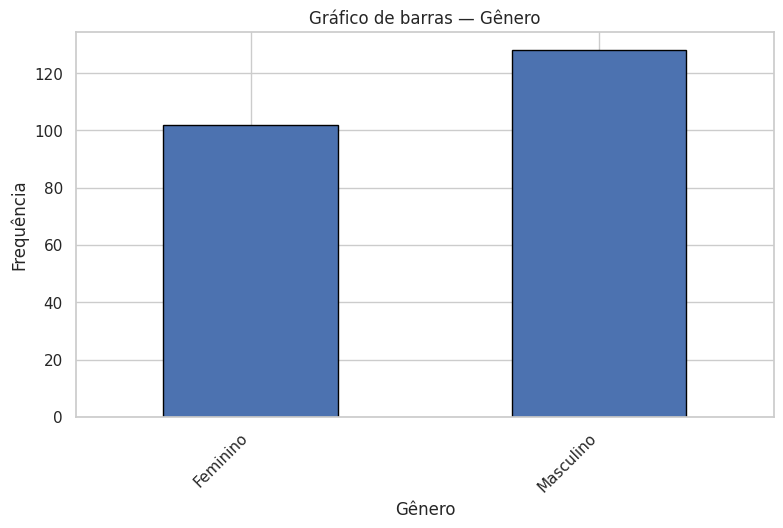

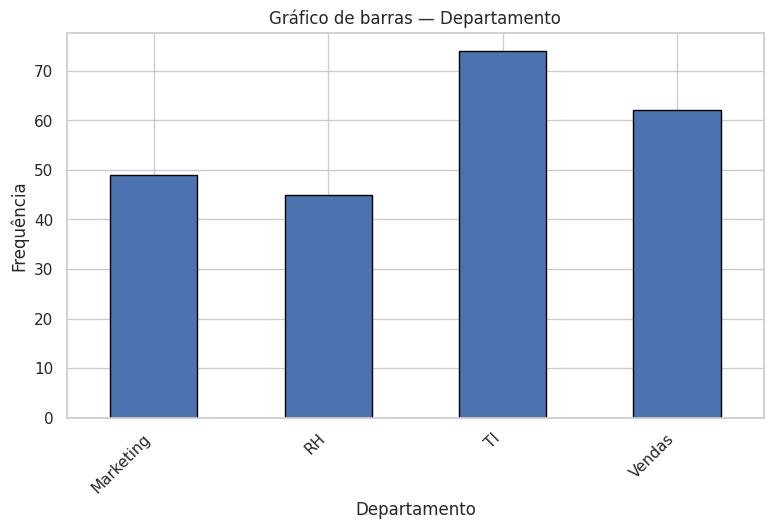

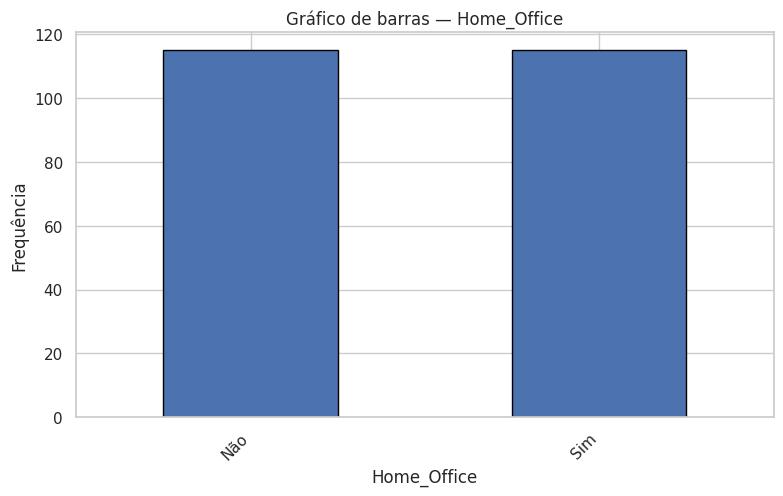

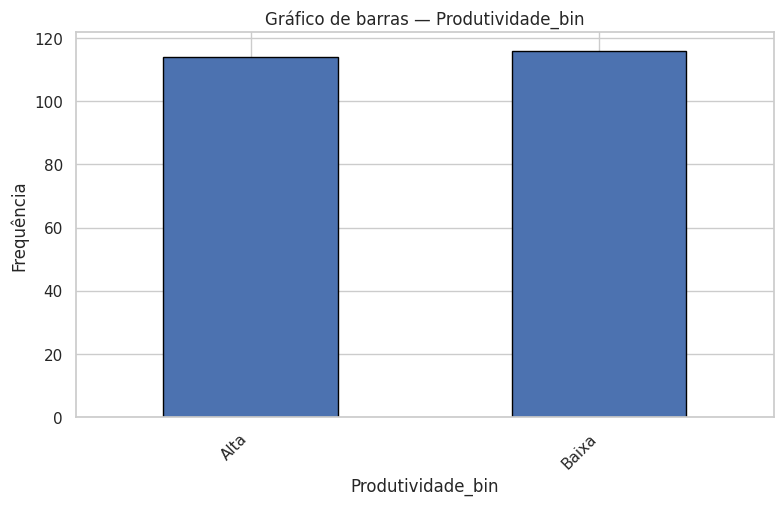

In [ ]:
for var in qualitativas:
    tab = pd.crosstab(index=df[var], columns='Frequência')
    tab.plot.bar(figsize=(9, 5), legend=False, edgecolor='black')
    plt.title(f'Gráfico de barras — {var}')
    plt.xlabel(var)
    plt.ylabel('Frequência')
    plt.xticks(rotation=45, ha='right')
    plt.show()
    print('\n')

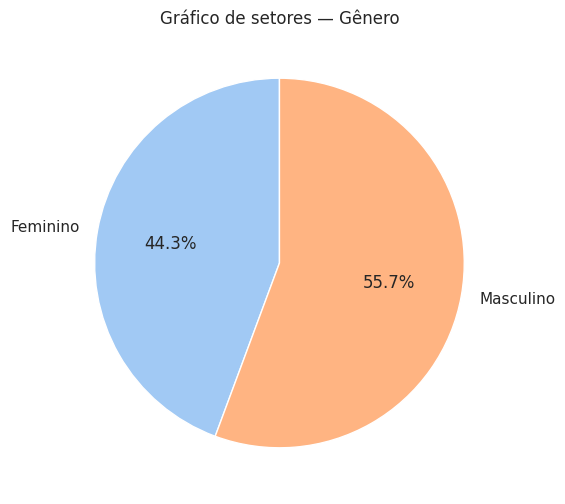

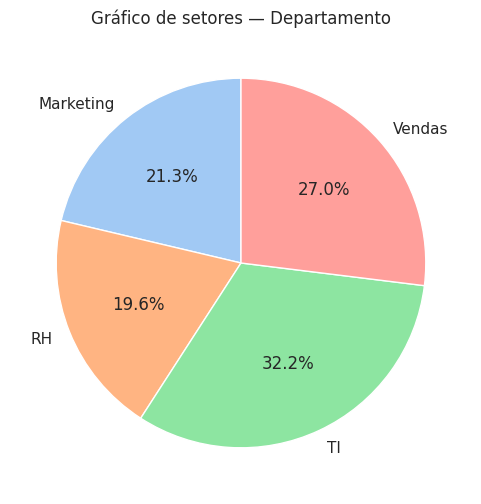

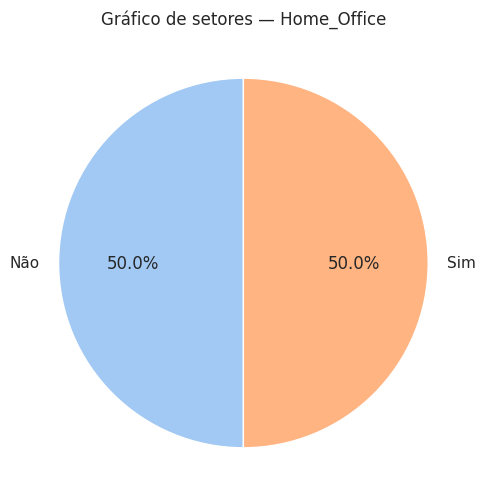

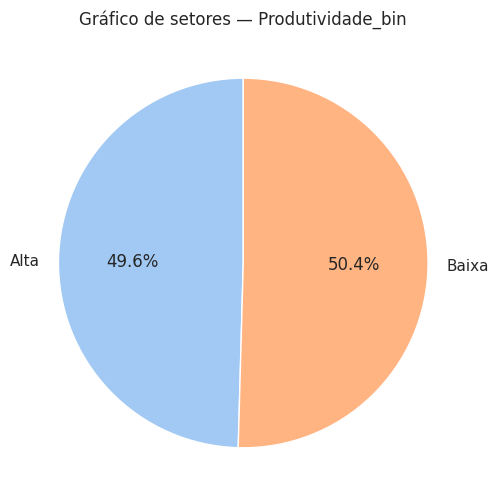

In [ ]:
for var in qualitativas:
    tab = pd.crosstab(index=df[var], columns='Frequência')
    tab.plot.pie(
        y='Frequência',
        autopct='%1.1f%%',
        figsize=(6, 6),
        colors=sns.color_palette("pastel"),
        legend=False,
        startangle=90
    )
    plt.title(f'Gráfico de setores — {var}')
    plt.ylabel('')
    plt.show()
    print('\n')

A variável `Gênero` é uma variável qualitativa nominal, pois classifica os funcionários em categorias sem ordem natural. Observa-se que a base possui 128 funcionários do gênero masculino e 102 do gênero feminino. Portanto, há uma leve predominância de funcionários masculinos na amostra. No entanto, a diferença entre as frequências não é tão elevada a ponto de indicar uma base extremamente desequilibrada em relação ao gênero.

A variável `Departamento` também é qualitativa nominal, pois indica a área de atuação do funcionário dentro da empresa. A maior frequência ocorre no departamento de TI, com 74 funcionários, seguido por Vendas, com 62 funcionários, Marketing, com 49 funcionários, e RH, com 45 funcionários. Assim, observa-se que o setor de TI é o mais representado na base, enquanto RH é o menos frequente. Essa diferença deve ser considerada nas interpretações posteriores, pois departamentos com maior número de funcionários podem influenciar mais fortemente os resultados gerais da análise exploratória.

A variável `Home_Office` indica se o funcionário trabalha ou não em regime de home-office. Trata-se de uma variável qualitativa nominal binária, com duas categorias: “Sim” e “Não”. A distribuição é perfeitamente equilibrada, com 115 funcionários em home-office e 115 funcionários sem home-office. Esse equilíbrio é interessante para a análise, pois permite comparar os dois grupos sem grande diferença de tamanho entre eles.

A variável `Produtividade_bin` foi criada a partir da mediana da variável `Produtividade`. Funcionários com produtividade acima da mediana foram classificados como de alta produtividade, enquanto funcionários com produtividade abaixo ou igual à mediana foram classificados como de baixa produtividade. A distribuição ficou praticamente equilibrada, com 114 funcionários classificados como “Alta” e 116 como “Baixa”. Esse equilíbrio ocorre porque a mediana divide aproximadamente a base em duas partes, embora os valores iguais à mediana tenham sido incluídos no grupo de baixa produtividade, como solicitado.

De modo geral, as tabelas de frequência e os gráficos mostram que as variáveis qualitativas apresentam distribuições relativamente bem definidas. `Gênero` apresenta leve predominância masculina, `Departamento` possui maior concentração em TI e Vendas, `Home_Office` está exatamente equilibrada entre “Sim” e “Não”, e `Produtividade_bin` também apresenta divisão quase igual entre alta e baixa produtividade. Essas informações são importantes porque permitem compreender a composição da base antes de investigar possíveis associações entre produtividade e as demais características dos funcionários.

##  Questão (d): análise das variáveis quantitativas

Para variáveis quantitativas, serão usadas medidas descritivas e visualizações como histogramas, boxplots, gráficos de violino e dispersão.

In [ ]:
quantitativas = [
    'Idade', 'Salário', 'Horas_Trabalhadas', 'Produtividade',
    'Satisfação', 'Tempo_Empresa', 'Cursos_Realizados'
]

round(df[quantitativas].describe(), 2)

,Idade,Salário,Horas_Trabalhadas,Produtividade,Satisfação,Tempo_Empresa,Cursos_Realizados
count,230.00,230.00,230.00,230.00,230.00,230.00,230.00
mean,30.55,8029.97,38.85,87.85,86.15,6.77,5.20
std,8.22,6556.33,5.82,12.24,12.06,5.96,4.22
min,18.00,2536.32,30.00,65.74,39.42,0.00,0.00
25%,24.00,2536.32,34.00,77.12,77.57,1.00,2.00
50%,29.00,5667.56,38.00,87.04,87.73,6.00,5.00
75%,35.00,12129.21,44.00,98.42,96.19,11.00,8.00
max,54.00,29052.82,48.00,112.06,100.00,30.00,20.00


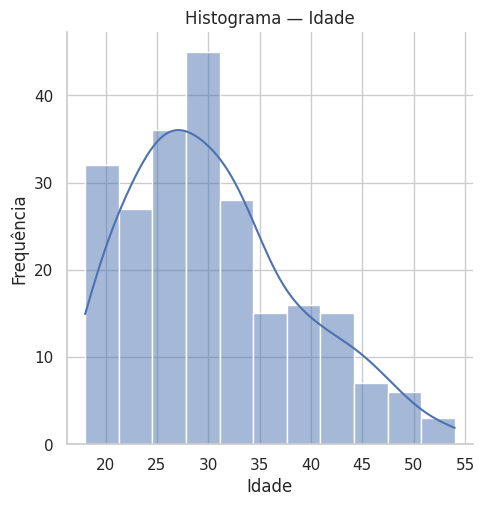

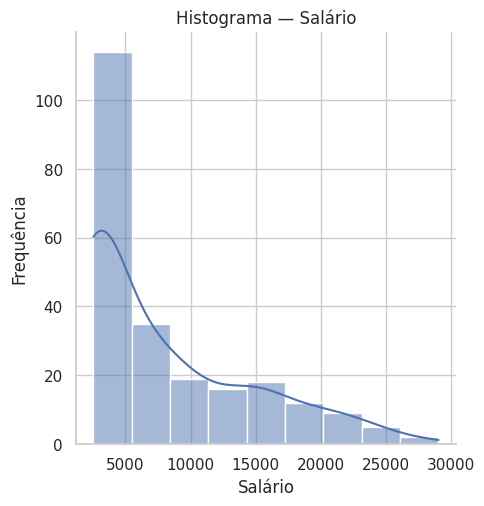

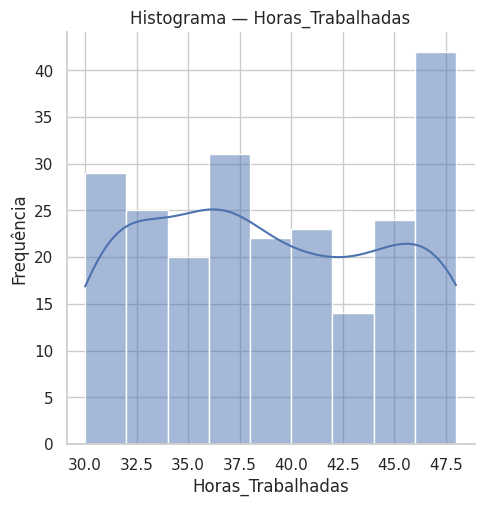

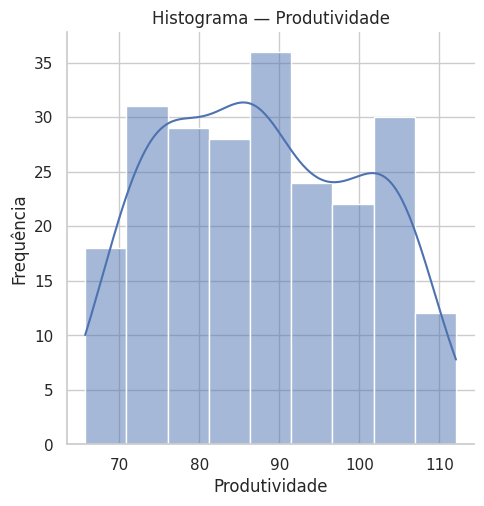

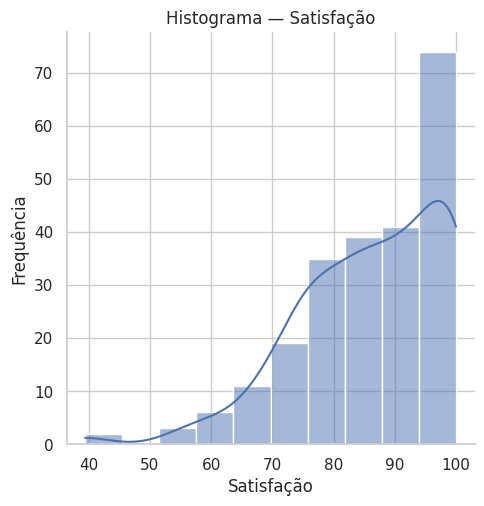

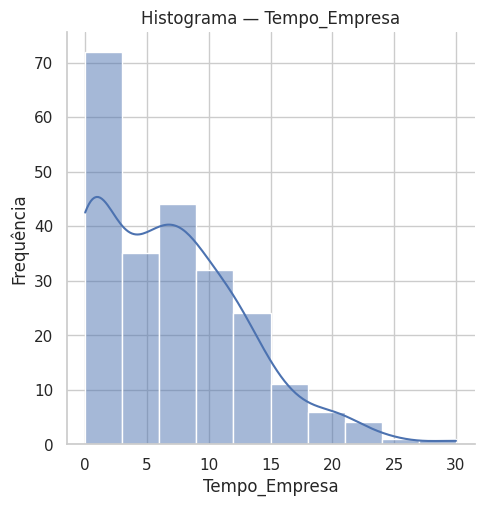

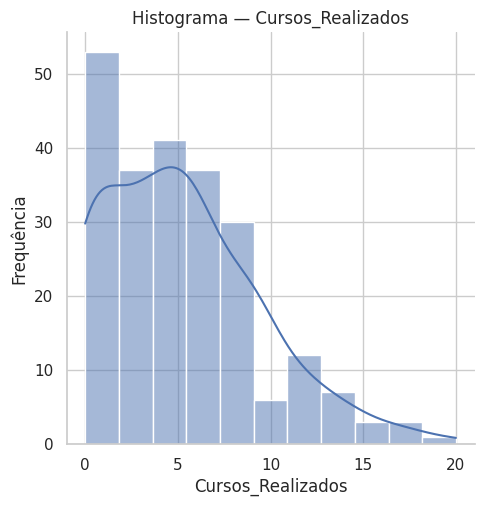

In [ ]:
for var in quantitativas:
    sns.displot(df[var], kde=True)
    plt.title(f'Histograma — {var}')
    plt.xlabel(var)
    plt.ylabel('Frequência')
    plt.show()
    print('\n')

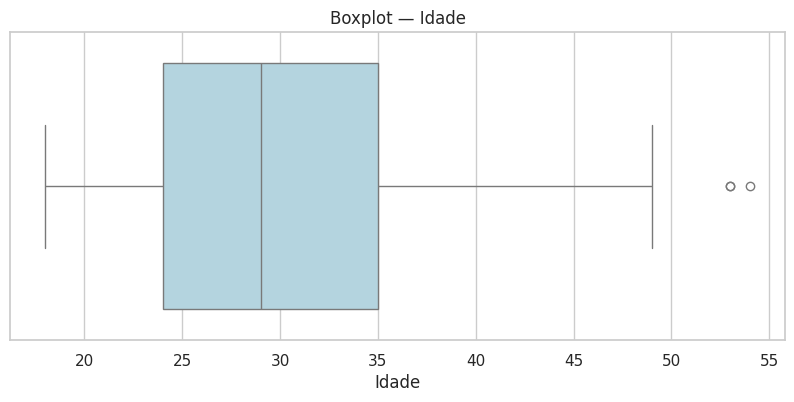

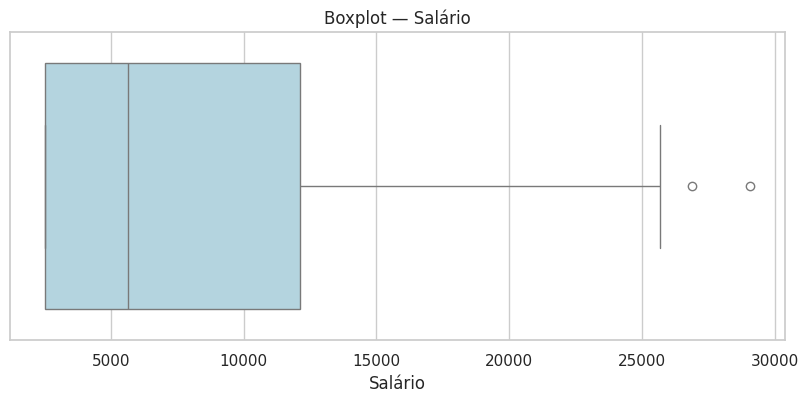

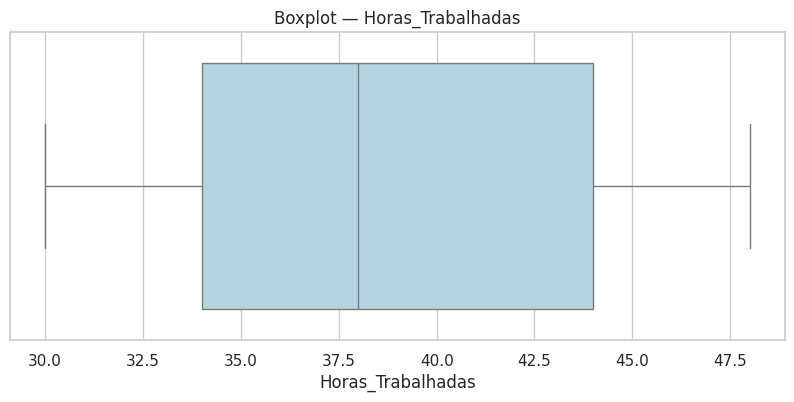

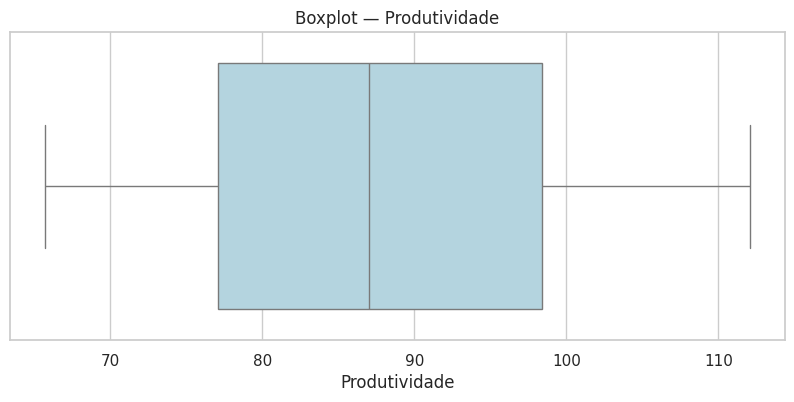

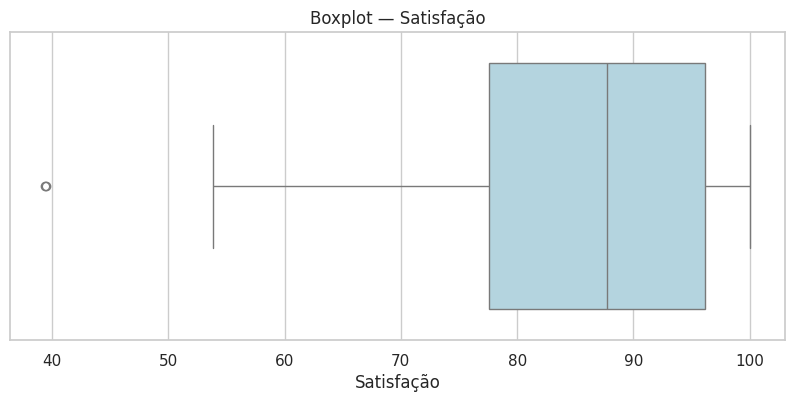

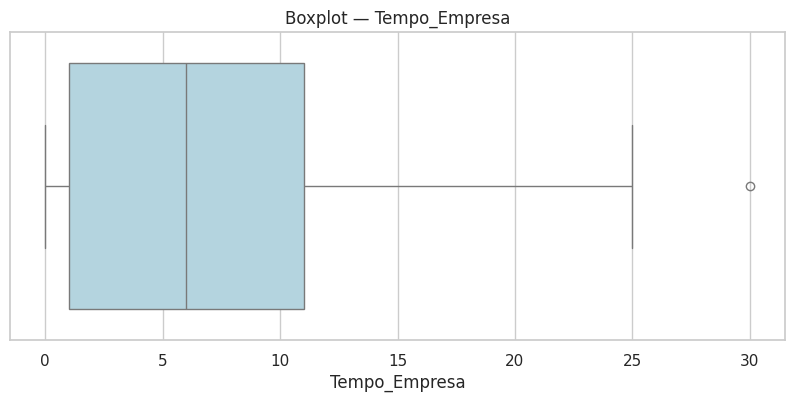

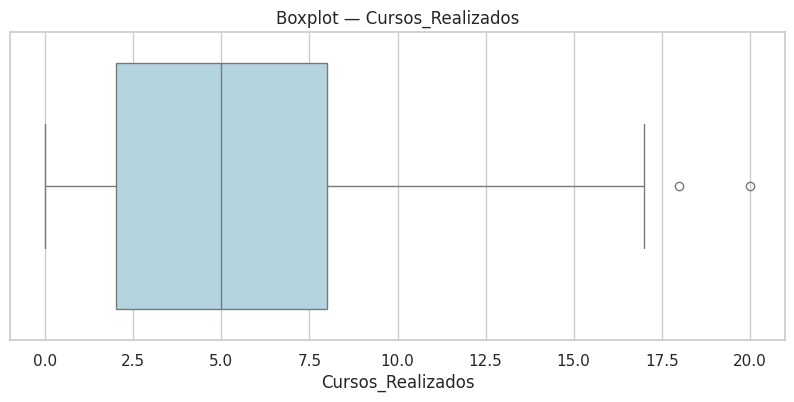

In [ ]:
for var in quantitativas:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[var], color='lightblue')
    plt.title(f'Boxplot — {var}')
    plt.show()
    print('\n')

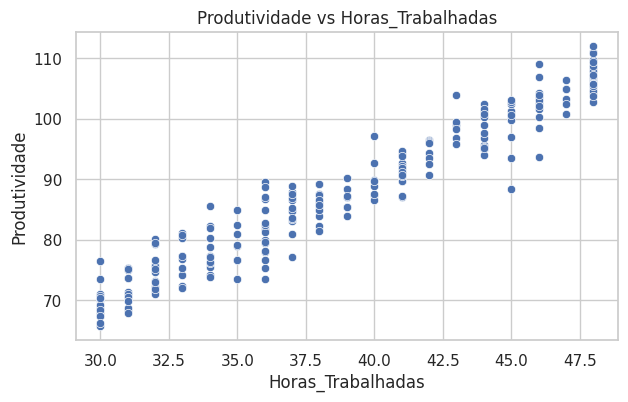

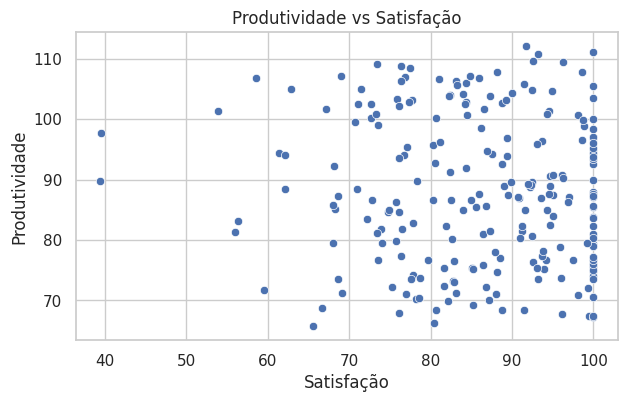

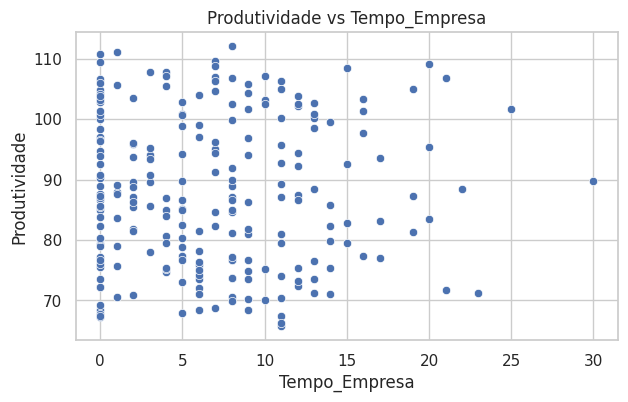

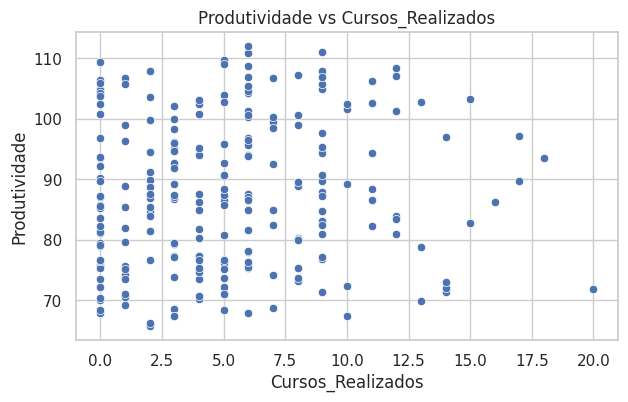

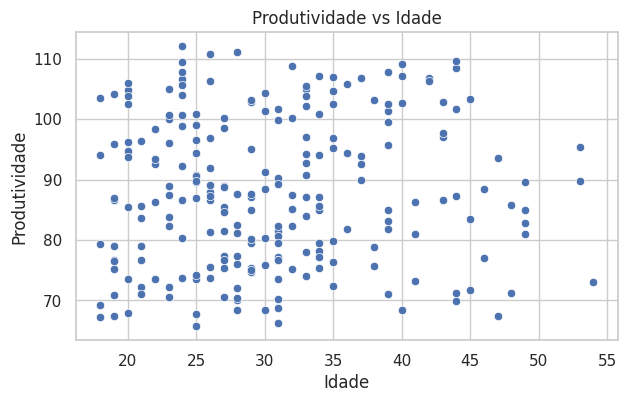

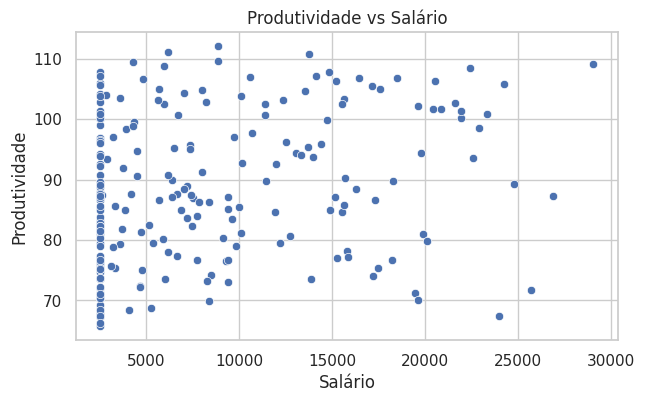

In [ ]:
for var in ['Horas_Trabalhadas', 'Satisfação', 'Tempo_Empresa', 'Cursos_Realizados', 'Idade', 'Salário']:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=df[var], y=df['Produtividade'])
    plt.title(f'Produtividade vs {var}')
    plt.xlabel(var)
    plt.ylabel('Produtividade')
    plt.show()
    print('\n')

A variável `Idade` apresenta média de aproximadamente 30,55 anos e mediana de 29 anos, indicando que a maior parte dos funcionários é relativamente jovem. Tem a presença de funcionários mais velhos, mas não representa a maioria dos funcionários.

A variável `Salário` apresenta maior dispersão em relação às demais variáveis quantitativas. A média salarial é de aproximadamente R\$ 8.029,97, enquanto a mediana é R\$ 5.667,56. Como a média é maior que a mediana, é possível notar uma assimetria, pois alguns funcionários com salários maiores aumentam a média geral. Essa característica também pode ser observada no histograma e no boxplot, nos quais se espera maior alongamento da distribuição para valores altos.

Em relação a `Horas_Trabalhadas`, a média é de 38,85 horas e a mediana é 38 horas. Esses valores próximos indicam uma distribuição relativamente equilibrada em torno do centro. Os quartis indicam que 50% dos funcionários trabalham entre 34 e 44 horas semanais, o que mostra a faixa central da distribuição. A variável é relevante para a análise porque pode estar associada diretamente à produtividade.

A variável `Produtividade` apresenta média de 87,85 e mediana de 87,04. A proximidade entre média e mediana sugere que a distribuição da produtividade não apresenta assimetria muito acentuada. Em outras palavras, não há uma diferença muito grande entre o valor médio e o valor que divide a base em duas partes de mesmo tamanho.

A partir dos quartis, é possível observar a faixa central da distribuição. O primeiro quartil indica que 25% dos funcionários possuem produtividade até aproximadamente 80,71, enquanto o terceiro quartil indica que 75% dos funcionários possuem produtividade até aproximadamente 95,06. Portanto, metade dos funcionários apresenta produtividade entre aproximadamente 80,71 e 95,06, mostrando que a maior parte dos valores se concentra em uma faixa relativamente próxima ao centro da distribuição.

O valor mínimo observado é aproximadamente 64,05, enquanto o valor máximo é aproximadamente 110,18. Isso indica que há uma amplitude considerável entre os funcionários com menor e maior produtividade. No entanto, essa diferença deve ser interpretada com cautela, pois a análise exploratória não permite afirmar, sozinha, quais fatores causam essas diferenças.

A variável `Satisfação` apresenta média de 86,15 e mediana de 87,73, com valores concentrados em níveis relativamente altos. O valor mínimo observado é 39,42, enquanto o máximo é 100, indicando que, embora a maioria dos funcionários apresente satisfação elevada, há alguns casos de satisfação consideravelmente menor.

A variável `Tempo_Empresa` apresenta média de 6,77 anos e mediana de 6 anos. A proximidade entre média e mediana indica que a maior parte dos funcionários está concentrada em torno de um tempo intermediário de permanência na empresa.

O primeiro quartil é igual a 3 anos, indicando que 25% dos funcionários possuem até 3 anos de empresa. Já o terceiro quartil é igual a 9 anos, indicando que 75% dos funcionários possuem até 9 anos de empresa. Assim, metade dos funcionários possui entre 3 e 9 anos de permanência na organização, o que sugere uma concentração relevante de funcionários com tempo de empresa intermediário.

O valor mínimo observado é 0 ano, indicando a presença de funcionários recém-ingressos ou com menos de um ano completo de empresa. Por outro lado, o valor máximo é 30 anos, o que mostra que há funcionários com vínculo bastante longo com a organização. Como o valor máximo está distante da mediana, há indício de assimetria à direita, isto é, a maioria dos funcionários possui tempo de empresa relativamente menor, mas alguns poucos funcionários apresentam permanência muito elevada.

Do ponto de vista da análise exploratória, `Tempo_Empresa` é uma variável relevante porque permite investigar se a experiência acumulada na organização parece estar associada à produtividade. Uma hipótese possível seria que funcionários com mais tempo de empresa conheçam melhor os processos internos e, por isso, apresentem maior produtividade. Por outro lado, também é possível que funcionários mais recentes tenham maior adaptação a novas ferramentas ou métodos de trabalho.

A variável `Cursos_Realizados` apresenta média de 5,20 cursos e mediana de 5 cursos. A proximidade entre essas medidas indica concentração em torno de valores intermediários, embora o máximo de 20 cursos mostre que alguns funcionários realizaram uma quantidade substancialmente maior de cursos. Essa variável pode ser analisada como possível melhora da capacitação profissional.

De modo geral, as medidas descritivas e os gráficos indicam que `Salário`, `Tempo_Empresa` e `Cursos_Realizados` apresentam maior possibilidade de assimetria, enquanto `Horas_Trabalhadas`, `Produtividade` e `Satisfação` parecem ter distribuições mais concentradas em torno de seus valores centrais. Os histogramas auxiliam na identificação do formato das distribuições, enquanto os boxplots permitem observar mediana e possíveis valores extremos.

## Questão (e): tabelas resumo e gráficos de associação com `Produtividade_bin`

Nesta etapa, a variável criada `Produtividade_bin` é comparada com as demais variáveis do conjunto de dados. Para variáveis quantitativas, serão comparadas medidas descritivas por grupo. Para variáveis qualitativas, serão construídas tabelas de dupla entrada e gráficos de barras empilhadas.

In [ ]:
for var in quantitativas:
    print(f'\nResumo da variável: {var}')

    tabela = df.groupby('Produtividade_bin')[var].agg(
        ['mean', 'median', 'std', 'min', 'max']
    )

    display(round(tabela, 2))
    print('\n')


Resumo da variável: Idade


,mean,median,std,min,max
Produtividade_bin,,,,,
Alta,30.82,30.0,8.14,18,53
Baixa,30.28,29.0,8.32,18,54





Resumo da variável: Salário


,mean,median,std,min,max
Produtividade_bin,,,,,
Alta,9527.15,7125.84,7149.99,2536.32,29052.82
Baixa,6558.61,3485.34,5564.00,2536.32,25677.80





Resumo da variável: Horas_Trabalhadas


...

,mean,median,std,min,max
Produtividade_bin,,,,,
Alta,85.50,87.82,12.90,39.42,100.0
Baixa,86.79,87.57,11.19,55.95,100.0





Resumo da variável: Tempo_Empresa


,mean,median,std,min,max
Produtividade_bin,,,,,
Alta,6.83,6.0,6.5,0,30
Baixa,6.72,6.0,5.4,0,23





Resumo da variável: Cursos_Realizados


,mean,median,std,min,max
Produtividade_bin,,,,,
Alta,5.51,5.0,4.17,0,18
Baixa,4.91,4.0,4.26,0,20


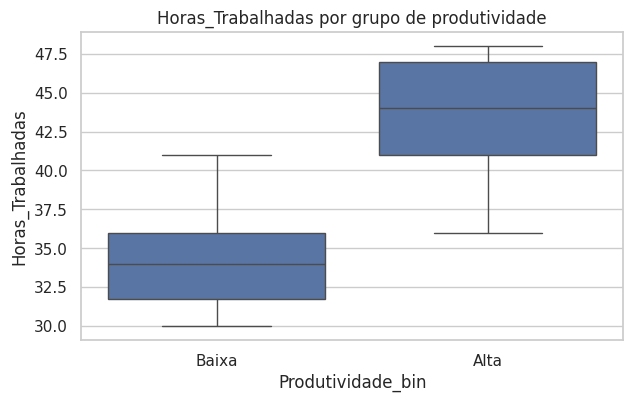

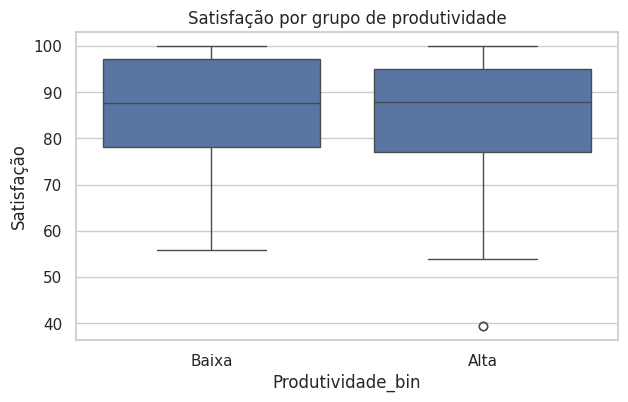

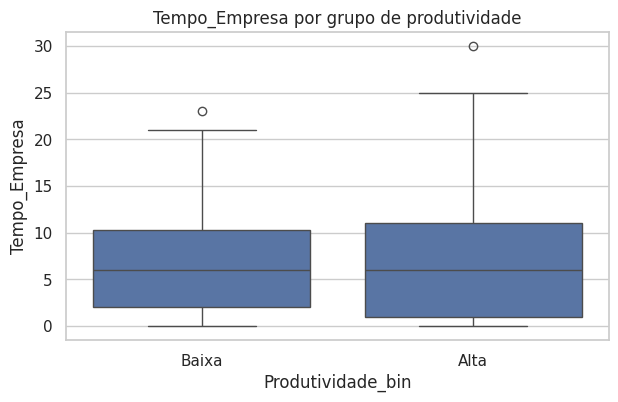

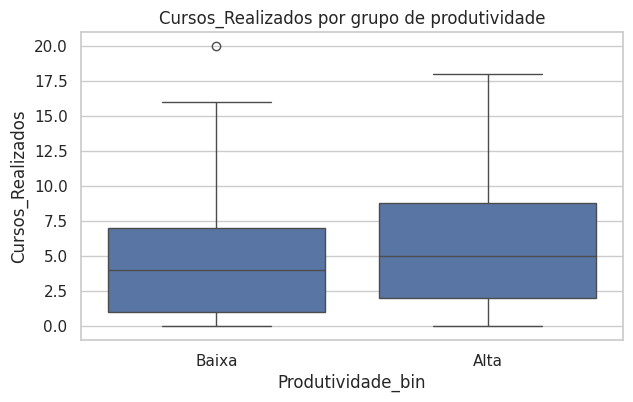

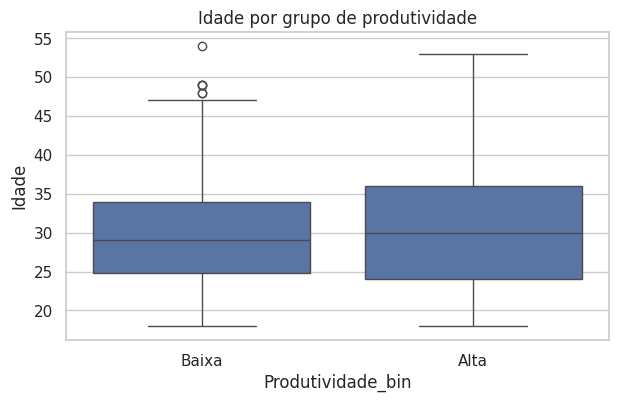

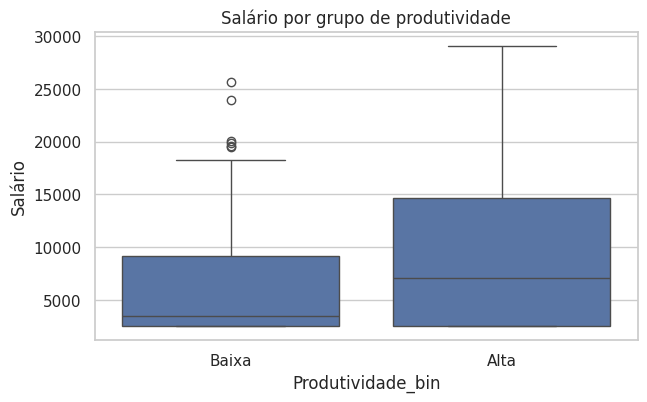

In [ ]:
for var in ['Horas_Trabalhadas', 'Satisfação', 'Tempo_Empresa', 'Cursos_Realizados', 'Idade', 'Salário']:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x='Produtividade_bin', y=var, data=df, order=['Baixa', 'Alta'])
    plt.title(f'{var} por grupo de produtividade')
    plt.xlabel('Produtividade_bin')
    plt.ylabel(var)
    plt.show()
    print('\n')

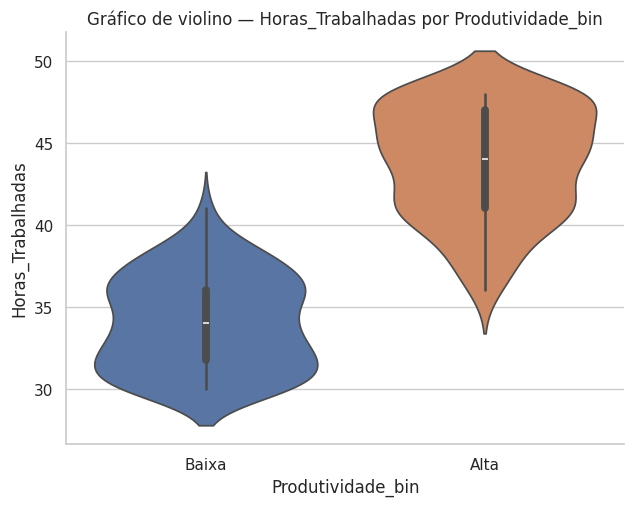

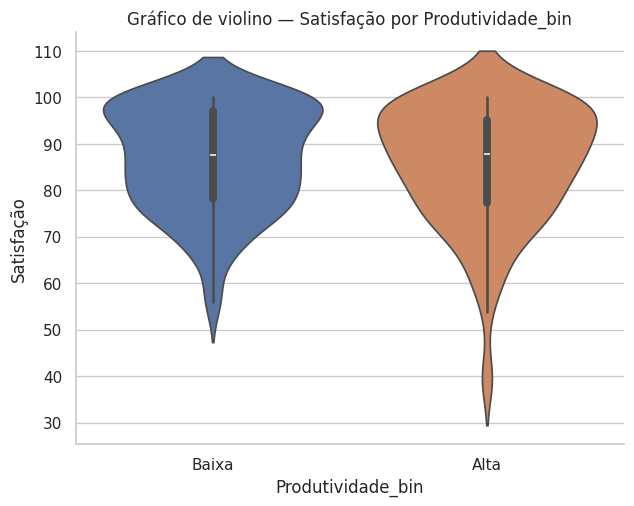

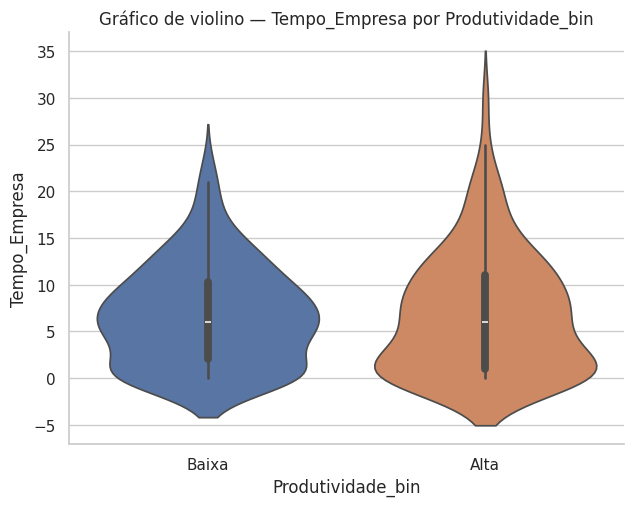

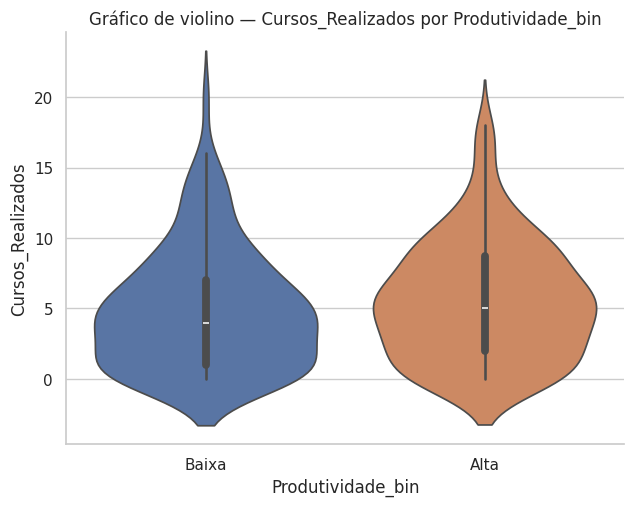

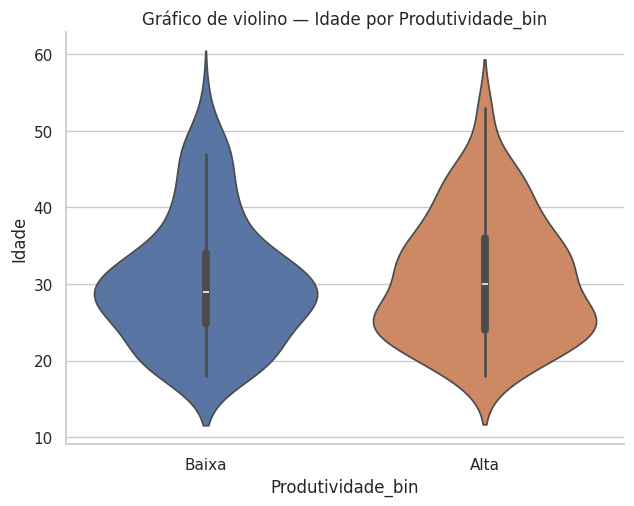

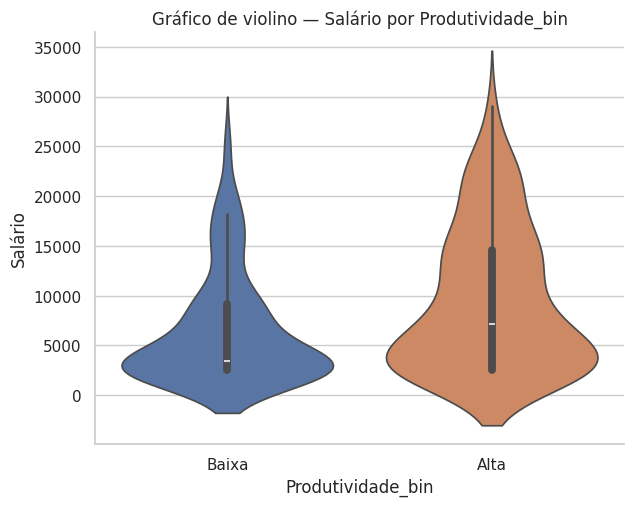

In [ ]:
for var in ['Horas_Trabalhadas', 'Satisfação', 'Tempo_Empresa', 'Cursos_Realizados', 'Idade', 'Salário']:

    sns.catplot(
        data=df,
        x='Produtividade_bin',
        y=var,
        hue='Produtividade_bin',
        kind='violin',
        order=['Baixa', 'Alta'],
        height=5,
        aspect=1.3,
        legend=False
    )

    plt.title(f'Gráfico de violino — {var} por Produtividade_bin')
    plt.xlabel('Produtividade_bin')
    plt.ylabel(var)
    plt.show()
    print('\n')

In [ ]:
for var in ['Gênero', 'Departamento', 'Home_Office',]:
    display(pd.crosstab(index=df[var], columns=df['Produtividade_bin'], margins=True))
    print('\n')
    print('Percentuais')
    display((pd.crosstab(index=df[var], columns=df['Produtividade_bin'], normalize='index') * 100).round(2))
    print('\n \n')

Produtividade_bin,Alta,Baixa,All
Gênero,,,
Feminino,51,51,102
Masculino,63,65,128
All,114,116,230




Percentuais


Produtividade_bin,Alta,Baixa
Gênero,,
Feminino,50.00,50.00
Masculino,49.22,50.78


Produtividade_bin,Alta,Baixa,All
Departamento,,,
Marketing,26,23,49
RH,18,27,45
TI,38,36,74
Vendas,32,30,62
All,114,116,230




Percentuais


Produtividade_bin,Alta,Baixa
Departamento,,
Marketing,53.06,46.94
RH,40.00,60.00
TI,51.35,48.65
Vendas,51.61,48.39


Produtividade_bin,Alta,Baixa,All
Home_Office,,,
Não,0,115,115
Sim,114,1,115
All,114,116,230




Percentuais


Produtividade_bin,Alta,Baixa
Home_Office,,
Não,0.00,100.00
Sim,99.13,0.87


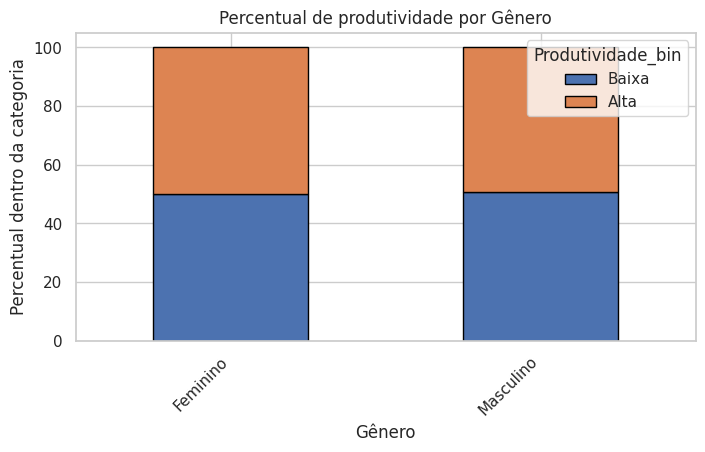

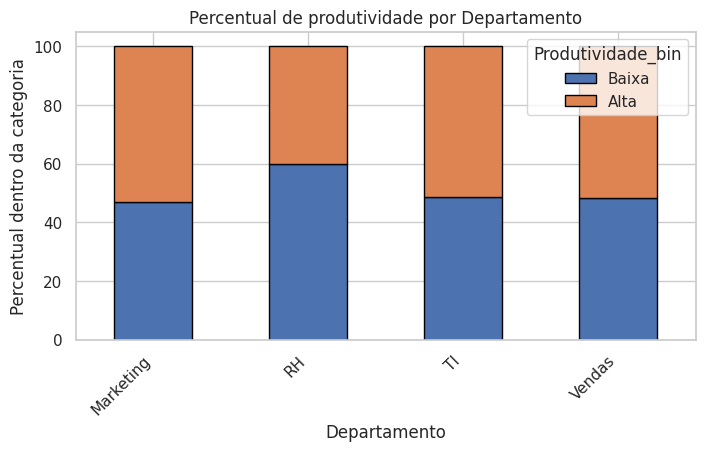

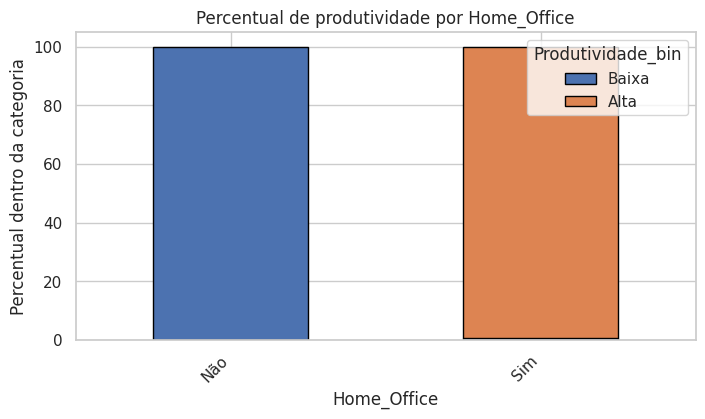

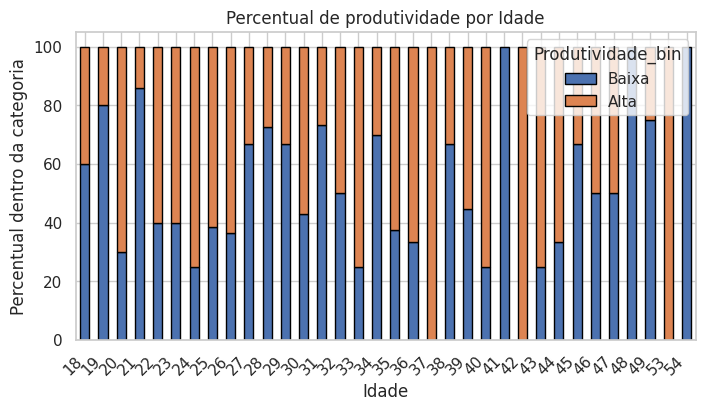

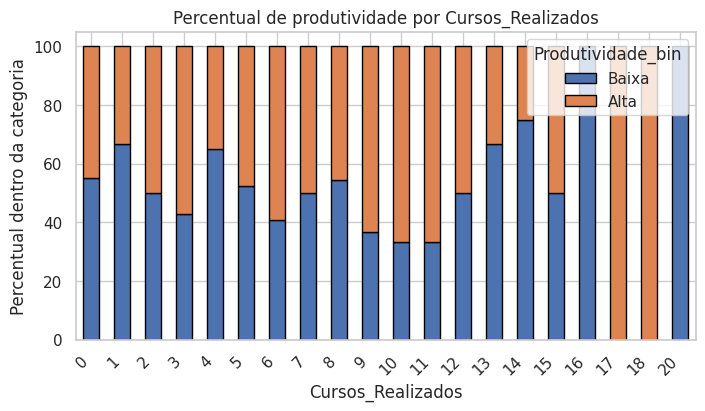

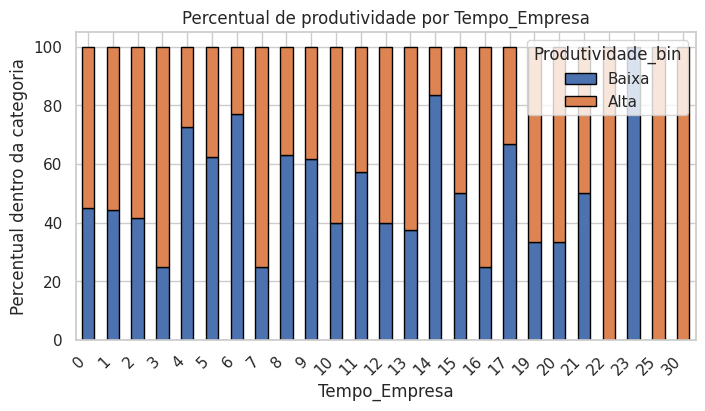

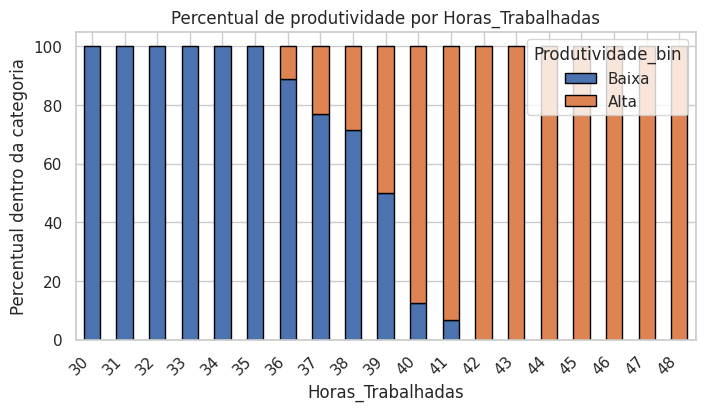

In [ ]:
for var in [
            'Gênero', 'Departamento', 'Home_Office', 'Idade',
            'Cursos_Realizados', 'Tempo_Empresa', 'Horas_Trabalhadas'
           ]:
    tabela = pd.crosstab(index=df[var], columns=df['Produtividade_bin'], normalize='index') * 100
    tabela = tabela[['Baixa', 'Alta']]
    tabela.plot.bar(stacked=True, figsize=(8, 4), edgecolor='black')
    plt.title(f'Percentual de produtividade por {var}')
    plt.xlabel(var)
    plt.ylabel('Percentual dentro da categoria')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Produtividade_bin')
    plt.show()
    print('\n')

Como `Produtividade_bin` é uma variável qualitativa binária, o objetivo foi verificar se os grupos de alta e baixa produtividade apresentam diferenças relevantes em relação às características dos funcionários.

Para as variáveis quantitativas, foram comparadas medidas como média, mediana, desvio-padrão, mínimo e máximo em cada grupo de produtividade. Essa comparação permite observar se os funcionários classificados como de alta produtividade tendem a apresentar valores maiores ou menores em determinadas variáveis. Além disso, os gráficos de violino e boxplots auxiliam na visualização da distribuição dos dados dentro de cada grupo, permitindo observar diferenças na posição central, dispersão e formato das distribuições.

A variável `Horas_Trabalhadas` apresenta a diferença mais evidente entre os grupos. O grupo de alta produtividade possui média e mediana maiores do que o grupo de baixa produtividade, indicando que os funcionários classificados como mais produtivos tendem também a trabalhar mais horas. Essa diferença também aparece visualmente nos gráficos, nos quais a distribuição do grupo de alta produtividade está deslocada para valores maiores de horas trabalhadas.

Para a variável `Satisfação`, as diferenças entre os grupos são menos evidentes. Embora possam existir pequenas variações entre as médias e medianas dos grupos, os valores parecem relativamente próximos. Dessa forma, a análise exploratória não indica uma separação tão clara entre alta e baixa produtividade com base apenas na satisfação dos funcionários.

Em relação ao `Tempo_Empresa`, as medidas descritivas dos grupos de alta e baixa produtividade também são próximas, especialmente em termos de mediana. Isso sugere que o tempo de permanência na empresa não parece diferenciar fortemente os grupos de produtividade nesta base. Portanto, não há evidência exploratória forte de que funcionários com maior tempo de empresa sejam necessariamente os mais produtivos.

A variável `Cursos_Realizados` apresenta pequenas diferenças entre os grupos, mas sem uma separação muito marcada. Embora o grupo de alta produtividade possa apresentar média ligeiramente maior, as medianas e a dispersão dos dados indicam que há sobreposição relevante entre os grupos. Assim, a quantidade de cursos realizados não parece ser, sozinha, uma característica fortemente associada à produtividade binária.

Para as variáveis qualitativas, foram utilizadas tabelas cruzadas e gráficos de barras proporcionais. A variável `Home_Office` apresenta uma associação exploratória bastante evidente com `Produtividade_bin`. Entre os funcionários que trabalham em home-office, há maior proporção de casos classificados como alta produtividade. Por outro lado, entre os funcionários que não trabalham em home-office, há maior proporção de baixa produtividade. Essa diferença sugere que o regime de trabalho pode estar associado ao nível de produtividade observado na base.

A variável `Departamento` apresenta algumas diferenças entre as áreas, mas a associação parece menos intensa do que em `Home_Office`. Alguns departamentos possuem proporções maiores de alta ou baixa produtividade, mas essas diferenças devem ser analisadas com cautela, pois os departamentos possuem tamanhos diferentes. Ainda assim, a tabela cruzada permite observar se determinados setores concentram mais funcionários de alta ou baixa produtividade.

Já a variável `Gênero` não parece apresentar uma associação forte com a produtividade binária. As proporções de alta e baixa produtividade entre os grupos masculino e feminino são relativamente próximas, o gênero não parece ser um fator que diferencia de forma marcante os níveis de produtividade.

De modo geral, as evidências da questão E indicam que as variáveis `Horas_Trabalhadas` e `Home_Office` são as que apresentam associação exploratória mais clara com `Produtividade_bin`. As demais variáveis, como `Idade`, `Satisfação`, `Tempo_Empresa`, `Cursos_Realizados`, `Gênero` e `Departamento`, apresentam diferenças menores ou menos consistentes entre os grupos. Como se trata de uma análise exploratória, essas conclusões indicam padrões observados nos dados, mas não permitem afirmar causalidade nem algum dado estatístico.

## 7. Questão (f): investigação dos pontos solicitados

A seguir, cada ponto solicitado no enunciado é analisado de forma exploratória.

### 7.1 Funcionários com alta produtividade trabalham mais horas?

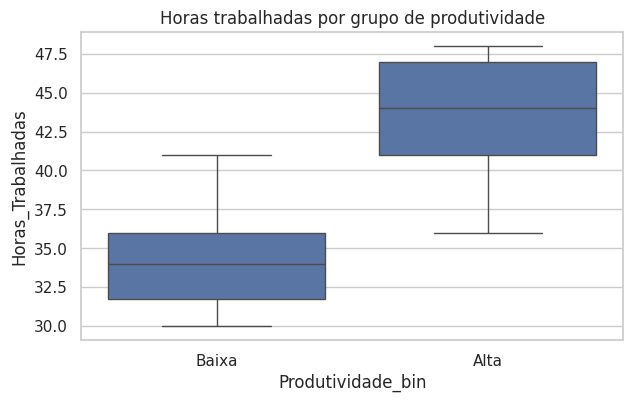

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Produtividade_bin', y='Horas_Trabalhadas', data=df, order=['Baixa', 'Alta'])
plt.title('Horas trabalhadas por grupo de produtividade')
plt.xlabel('Produtividade_bin')
plt.ylabel('Horas_Trabalhadas')
plt.show()

Sim, o grupo de alta produtividade tem média de **43,79 horas**, enquanto o grupo de baixa produtividade tem média de **34,00 horas**. Além disso, os boxplots mostram pouca sobreposição entre os grupos, indicando que `Horas_Trabalhadas` parece estar fortemente associada à classificação de produtividade.

### 7.2 Funcionários com alta produtividade possuem maior satisfação?

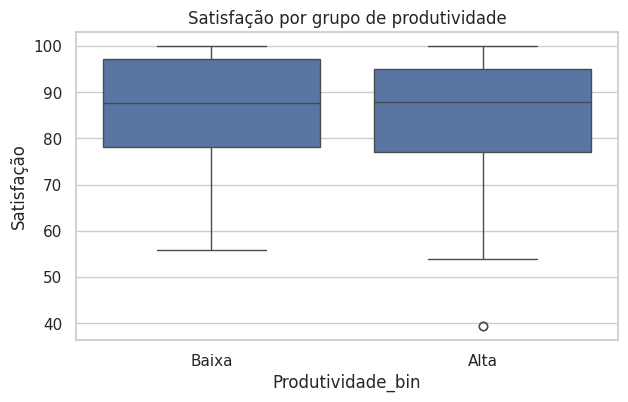

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Produtividade_bin', y='Satisfação', data=df, order=['Baixa', 'Alta'])
plt.title('Satisfação por grupo de produtividade')
plt.xlabel('Produtividade_bin')
plt.ylabel('Satisfação')
plt.show()

Não há evidências clara de que os funcionários de alta produtividade tenham maior satisfação. A média de satisfação é **85,50** no grupo de alta produtividade e **86,79** no grupo de baixa produtividade. As medianas são muito próximas: **87,82** para alta produtividade e **87,57** para baixa produtividade. Portanto, a satisfação não parece diferenciar fortemente os grupos.

### 7.3 Funcionários com alta produtividade permanecem mais tempo na empresa?

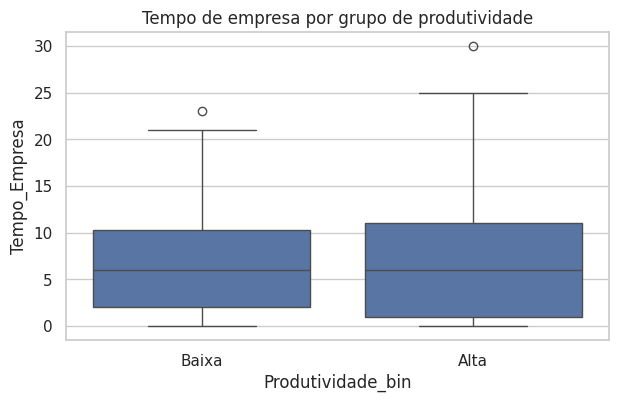

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Produtividade_bin', y='Tempo_Empresa', data=df, order=['Baixa', 'Alta'])
plt.title('Tempo de empresa por grupo de produtividade')
plt.xlabel('Produtividade_bin')
plt.ylabel('Tempo_Empresa')
plt.show()

Não há evidência forte nesse sentido. A média de tempo de empresa é **6,83 anos** para alta produtividade e **6,72 anos** para baixa produtividade, e as medianas são iguais a **6 anos** nos dois grupos. Assim, `Tempo_Empresa` parece ter associação fraca ou praticamente inexistente com a produtividade binária nesta amostra.

### 7.4 Funcionários com alta produtividade realizam mais cursos?

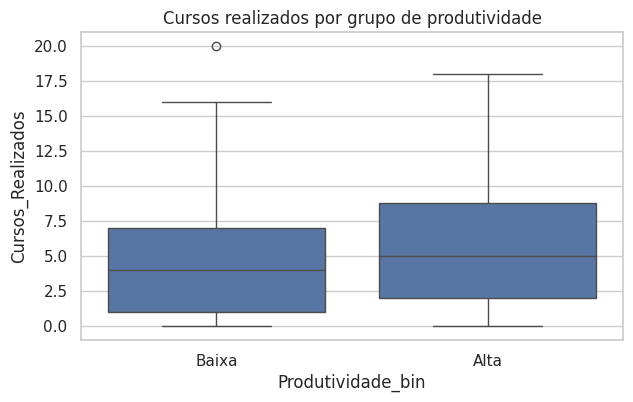

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Produtividade_bin', y='Cursos_Realizados', data=df, order=['Baixa', 'Alta'])
plt.title('Cursos realizados por grupo de produtividade')
plt.xlabel('Produtividade_bin')
plt.ylabel('Cursos_Realizados')
plt.show()

Há uma diferença pequena a favor do grupo de alta produtividade: média de **5,51 cursos** contra **4,91 cursos** no grupo de baixa produtividade. A mediana também é um pouco maior no grupo de alta produtividade: **5 cursos** contra **4 cursos**. Entretanto, a sobreposição entre os grupos é grande, então essa associação parece fraca quando comparada a `Horas_Trabalhadas` e `Home_Office`.

### 7.5 Funcionários de alta produtividade atuam em determinados departamentos?

In [ ]:
pd.crosstab(index=df['Departamento'], columns=df['Produtividade_bin'], margins=True)

Produtividade_bin,Alta,Baixa,All
Departamento,,,
Marketing,26,23,49
RH,18,27,45
TI,38,36,74
Vendas,32,30,62
All,114,116,230


In [ ]:
(pd.crosstab(index=df['Departamento'], columns=df['Produtividade_bin'], normalize='index') * 100).round(2)

Produtividade_bin,Alta,Baixa
Departamento,,
Marketing,53.06,46.94
RH,40.00,60.00
TI,51.35,48.65
Vendas,51.61,48.39


A associação com departamento parece moderada a fraca. O departamento de RH apresenta maior proporção de baixa produtividade: **60,00%** dos funcionários de RH estão no grupo de baixa produtividade. Marketing, TI e Vendas apresentam proporções próximas de 50% em cada grupo, com ligeira maioria de alta produtividade. Portanto, o departamento pode sugerir alguma diferença, principalmente para RH, mas não há separação tão forte quanto em `Horas_Trabalhadas` ou `Home_Office`.

### 7.6 Funcionários com alta produtividade trabalham em regime de home-office?

In [ ]:
(pd.crosstab(index=df['Home_Office'], columns=df['Produtividade_bin'], normalize='index') * 100).round(2)

Produtividade_bin,Alta,Baixa
Home_Office,,
Não,0.00,100.00
Sim,99.13,0.87


Sim. A associação exploratória entre `Home_Office` e `Produtividade_bin` é extremamente forte nesta amostra. Entre os funcionários que não fazem home-office, **100,00%** estão no grupo de baixa produtividade. Entre os que fazem home-office, **99,13%** estão no grupo de alta produtividade. Esse padrão indica forte associação descritiva entre o regime de home-office e a classificação de produtividade.

## Questão (g): variáveis com associação aparentemente mais forte

Com base nas tabelas resumo, nos boxplots, gráficos de violino e tabelas de dupla entrada, as variáveis que parecem apresentar associação mais forte com `Produtividade_bin` são:

1. **Home_Office**: a separação é quase perfeita. Dos funcionários sem home-office, 100% estão em baixa produtividade; dos funcionários com home-office, 99,13% estão em alta produtividade.
2. **Horas_Trabalhadas**: o grupo de alta produtividade trabalha, em média, 43,79 horas, enquanto o grupo de baixa produtividade trabalha, em média, 34,00 horas. A diferença média é de 9,79 horas, com pouca sobreposição visual nos boxplots.
3. **Salário**: também aparece diferença relevante: o grupo de alta produtividade tem salário médio de 9527,15 e mediana de 7125,84, enquanto o grupo de baixa produtividade tem salário médio de 6558,61 e mediana de 3485,34. Porém, a variável `Salário` apresenta alta dispersão e assimetria.

As variáveis `Satisfação`, `Tempo_Empresa`, `Cursos_Realizados`, `Idade` e `Gênero` parecem apresentar associação fraca ou pouco evidente com a produtividade binária. `Departamento` apresenta uma diferença mais perceptível para RH, mas ainda assim com intensidade menor do que `Home_Office` e `Horas_Trabalhadas`.

## Questão (h): limitações da análise exploratória e análises complementares

Esta análise é **exploratória** e, portanto, permite identificar padrões, diferenças descritivas e possíveis associações entre variáveis. Porém, ela não permite concluir, sozinha, que uma variável causa maior ou menor produtividade. Por exemplo, embora `Home_Office` esteja fortemente associado à alta produtividade nesta amostra, não é possível afirmar apenas com estes gráficos e tabelas que o home-office causa aumento de produtividade. Pode haver outras variáveis relacionadas, como tipo de função, perfil dos funcionários, política de alocação da empresa ou critérios de seleção para home-office.

Além disso, as associações observadas não necessariamente possuem **significância estatística**, pois não foram aplicados procedimentos inferenciais. Uma limitação importante é que as associações observadas nas tabelas e gráficos não implicam causalidade. A análise exploratória permite identificar padrões nos dados, mas não permite concluir que uma variável seja a causa direta da produtividade. Para isso, seriam necessárias análises complementares, com métodos estatísticos apropriados e controle de outras variáveis que também podem influenciar a produtividade. A transformação de `Produtividade` em variável binária também simplifica a informação, pois funcionários logo acima e logo abaixo da mediana podem ser bastante parecidos, mas passam a ser classificados em grupos distintos.

Para uma análise confirmatória, poderiam ser consideradas análises complementares como: testes de hipóteses para comparar grupos, medidas formais de associação entre variáveis qualitativas, intervalos de confiança e modelos estatísticos que permitam avaliar simultaneamente o efeito de várias variáveis sobre a produtividade. Como `Produtividade_bin` é binária, uma análise posterior poderia estudar a probabilidade de alta produtividade em função das demais características. Se a variável `Produtividade` original fosse mantida como quantitativa, também seria possível analisar sua relação com as variáveis explicativas sem perder informação pelo corte na mediana. Essas análises confirmatórias teriam a implicação de avaliar se os padrões encontrados visualmente são consistentes do ponto de vista estatístico, controlando melhor a incerteza amostral e possíveis fatores de confusão.

## 10. Conclusão geral

A análise exploratória sugere que as características mais associadas à produtividade binária são `Home_Office` e `Horas_Trabalhadas`. Funcionários em regime de home-office aparecem quase totalmente no grupo de alta produtividade, enquanto funcionários sem home-office aparecem no grupo de baixa produtividade. Além disso, funcionários de alta produtividade trabalham mais horas, em média, do que os de baixa produtividade. Por outro lado, variáveis como satisfação, tempo de empresa, idade, gênero e número de cursos realizados não apresentam diferenças tão expressivas entre os grupos. O departamento RH apresenta maior proporção de baixa produtividade, mas essa associação é menos forte do que as observadas para home-office e horas trabalhadas.